# Constante van Planck bepalen

# Labjournaal 
## General

**Names: Pieter Broerse & Frederik Roerink**  

**Title of the experiment: Constante van Planck bepaling**  

**Starting date: 08/01/2025**  

**Expected enddate: 23/01/2025**  

**Goal of the experiment: Bepalen van de constante van Planck met de golflengte en knee-voltage van verschillende LED's** 

**Research question: Is de constante van Planck nauwkeurig te bepalen met de golflengte en knee-voltage van verschillende LED's?**  

**Expectations or Hypothesis: We verwachten dat de gevonden waarde uit de experimenten niet strijdig is met de literatuurwaarde voor de constante van Planck**  

**Desired accuracy: 5%**  

In [181]:
# Importing important data sets
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import curve_fit

# De golflengte bereken van alle kleuren van de regenboog


## Preparation
 

**Assignments:**  N.v.t

**Method:** In dit experiment wordt de golflengte van verschillende LED's bepaald met behulp van een diffractierooster. Het experiment maakt gebruik van een niet symmetrische opstelling, waarbij de invallende lichtstraal niet loodrecht op het rooster staat. Hierdoor moet de diffractiehoek worden bepaald met behulp van geometrie.

**Theory:** Voor een diffractierooster geldt:

$$ d*sin(i) + m*\lambda = d*sin(u_m) $$

waarbij:
- $m$ het orde getal (hier steeds m=1)
- $d$ de roosterafstand
- $i$ de invalshoek van het licht
- $u_m$ de uitvalshoek van het licht

De hoek $u_m$ kan niet direct worden afgelezen, maar wordt bepaald met behulp van geometrie uit de gemeten afstanden $a$,$d$ en $L$, zoals weergegeven in Fig 1. Omdat het scherm loodrecht op de lichtbundel staat, volgt voor de uitvalshoek:

$$ u_m = arctan((a+d)/L) - 1/2*arctan(a/L) $$

Met deze hoek wordt vervolgens de golflengte van het licht berekend.


**Independent variable:** De kleur van de LED (rood,oranje,geel,groen,blauw, en paars) 

**Dependent variable:**  De golflengte $\lambda$ van het licht (in nanometers)

**Controlled variables:** 
- Type en kwaliteit van het diffractierooster
- Intensiteit van de lichtbron
- Afstand $L$ tussen rooster en sherm
- Omgevingslicht
- Geometrische uitlijning van de opstelling
- Orde getal $m$ = 1


**Measurement instruments \& Settings:** 
- Diffractierooster (met bekende roosterafstand $d$)
- Lichbron 
- Meetlat of liniaal om $x$ te meten
- Gradenboog

**Procedure:** 
1. Plaats de LED achter een spleet en lens zodat een evenwijdige lichtbundel ontstaat.
2. Laat het licht onder een vaste invalshoek op het diffractierooster vallen.
3. Plaats het scherm op een afstand $L$ achter het rooster
4. Bepaal op het scherm:
- de positie van orde 0
- de positie van de eerste orde
5. Meet de afstanden $a$ en $d$ zoals weergegeven in Fig 1.
6. Bereken de uitvalshoek $u_m$
7. Bereken de golflengte $\lambda$
8. Herhaal dit voor elke LED-kleur


**Notes:**
- Meet meerdere keren voor elke kleur en neem het gemiddelde voor nauwkeurigheid
- Houd het zo donker mogelijk tijdens metingen
- Zorg dat het diffractierooster schoon is en stabiel staat.  




## Opstelling: 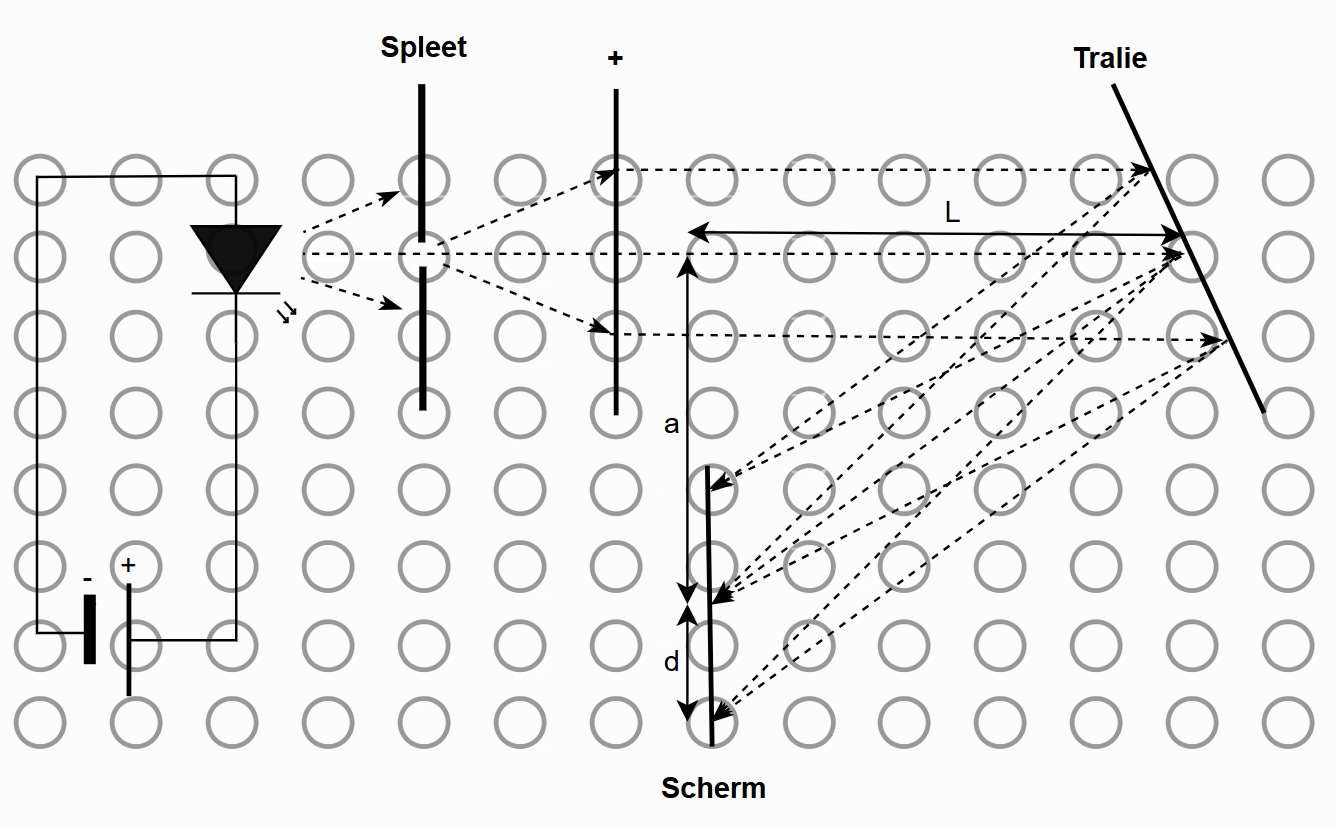

In [182]:
# De opstelling

Diffcratierooster = 600  # lijnen / mm
d = (1/600 )* 1e-3

L = 1 # meter tot de meetplaat
u_L = 0.01 # meter onzekerheid
u_x = 0.01 # meter
u_a = 0.001


In [183]:
# Functies definieren

def mean(x1,x2,x3):
    return (x1+x2+x3)/3

def um(a,x,L):
    return np.arctan((a+x)/L) - 0.5*np.arctan(a/L)

def golflengte(um):
    return d * np.sin(um)

def golflengte_to_nm(l):
    return l*1e9

def golflengte_onzekerheid(a, x, u_a, u_x, u_L):
    um_val = um(a, x, L)

    # partial derivatives
    da = 1/(L*(1+((a+x)/L)**2)) - 0.5/(L*(1+(a/L)**2))
    dx = 1/(L*(1+((a+x)/L)**2))
    dL = -(a+x)/(L**2*(1+((a+x)/L)**2)) + a/(2*L**2*(1+(a/L)**2))

    u_um = np.sqrt((da*u_a)**2 + (dx*u_x)**2 + (dL*u_L)**2)
    u_lambda = d * np.cos(um_val) * u_um
    return u_lambda


In [184]:
# De golflengte van rood licht berekenen

# Rode Led
r_x_1 = 0.40
r_x_2 = 0.37
r_x_3 = 0.42
r_a =  0.0142

x_rood = mean(r_x_1,r_x_2,r_x_3)

um_r = um(r_a,x_rood,L)

golflengte_r = golflengte(um_r)

print(golflengte_r)

golflengte_r_nm = golflengte_to_nm(golflengte_r)

print(golflengte_r_nm)

u_r_nm = golflengte_to_nm(golflengte_onzekerheid(r_a,x_rood,u_a,u_x,u_L))




6.224384740159374e-07
622.4384740159375


In [185]:
# De golflengte van oranje licht

# oranje led
o_x_1 = 0.39
o_x_2 = 0.40
o_x_3 = 0.36
r_o = 0.0309

x_oranje = mean(o_x_1,o_x_2,o_x_3)

um_o = um(r_o,x_oranje,L)

golflengte_o = golflengte(um_o)

print(golflengte_o)

golflengte_o_nm = golflengte_to_nm(golflengte_o)

print(golflengte_o_nm)

u_o_nm = golflengte_to_nm(golflengte_onzekerheid(r_o,x_oranje,u_a,u_x,u_L))

6.139744103360182e-07
613.9744103360182


In [186]:
# De golflengte van geel licht 

# Geel led
g_x_1 = 0.35
g_x_2 = 0.37
g_x_3 = 0.34
r_g = 0.0367

x_geel = mean(g_x_1,g_x_2,g_x_3)

mu_g = um(r_g,x_geel,L)

golflengte_g = golflengte(mu_g)

print(golflengte_g)

golflengte_g_nm = golflengte_to_nm(golflengte_g)

print(golflengte_g_nm)

u_g_nm = golflengte_to_nm(golflengte_onzekerheid(r_g,x_geel,u_a,u_x,u_L))

5.770401152407183e-07
577.0401152407183


In [187]:
# De golflengte van groen licht

# Groene Led
gr_x_1 = 0.31
gr_x_2 = 0.34
gr_x_3 = 0.31
a_gr = 0.0439

x_groen = mean(gr_x_1,gr_x_2,gr_x_3)

um_gr = um(a_gr,x_groen,L)

golflengte_gr = golflengte(um_gr)

print(golflengte_gr)

golflengte_gr_nm = golflengte_to_nm(golflengte_gr)

print(golflengte_gr_nm)

u_gr_nm = golflengte_to_nm(golflengte_onzekerheid(a_gr,x_groen,u_a,u_x,u_L))

5.354462715596354e-07
535.4462715596354


In [188]:
# De golflengte van blauw licht

# Blauw led
b_x_1 = 0.26
b_x_2 = 0.24
b_x_3 = 0.30
a_b = 0.0605

x_blauw = mean(b_x_1,b_x_2,b_x_3)

um_b = um(a_b,x_blauw,L)

golflengte_b = golflengte(um_b)

print(golflengte_b)

golflengte_b_nm = golflengte_to_nm(golflengte_b)

print(golflengte_b_nm)

u_b_nm = golflengte_to_nm(golflengte_onzekerheid(a_b,x_blauw,u_a,u_x,u_L))

4.7015842012101206e-07
470.15842012101206


In [189]:
# De golflengte van paars (violet) licht

# Paarse led
p_x_1 = 0.20
p_x_2 = 0.23
p_x_3 = 0.19
a_p = 0.0847

x_paars = mean(p_x_1,p_x_2,p_x_3)

um_p = um(a_p,x_paars,L)

golflengte_p = golflengte(um_p)

print(golflengte_p)

golflengte_p_nm = golflengte_to_nm(golflengte_p)

print(golflengte_p_nm)

u_p_nm = golflengte_to_nm(golflengte_onzekerheid(a_p,x_paars,u_a,u_x,u_L))

3.9822421007306247e-07
398.22421007306247


In [190]:
# Samenvatting antwoorden

# Rood licht
print("λ rood =", np.round(golflengte_r_nm), '±', np.round(u_r_nm),  "nm")
# Oranje licht
print("λ oranje =", np.round(golflengte_o_nm), '±', np.round(u_o_nm), "nm")
# Geel licht
print("λ geel =", np.round(golflengte_g_nm), '±', np.round(u_g_nm), "nm")
# Groen licht
print("λ groen =", np.round(golflengte_gr_nm), '±', np.round(u_gr_nm), "nm")
# Blauw licht
print("λ blauw =", np.round(golflengte_b_nm), '±', np.round(u_b_nm), "nm")
# Paars licht
print("λ paars =", np.round(golflengte_p_nm), '±', np.round(u_p_nm), "nm")

λ rood = 622.0 ± 14.0 nm
λ oranje = 614.0 ± 14.0 nm
λ geel = 577.0 ± 14.0 nm
λ groen = 535.0 ± 15.0 nm
λ blauw = 470.0 ± 15.0 nm
λ paars = 398.0 ± 15.0 nm


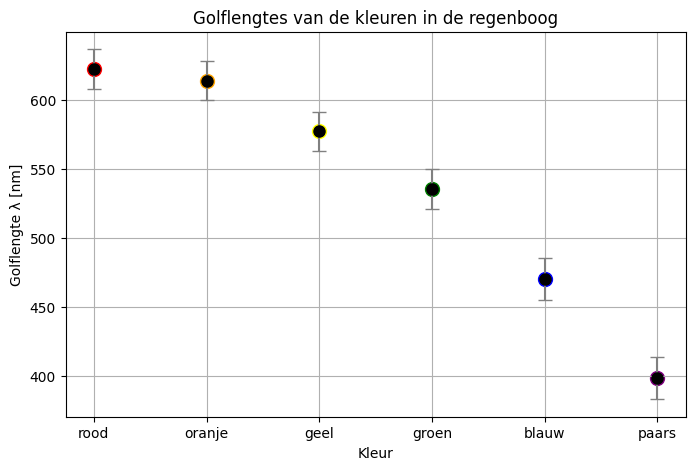

In [191]:
# Alle golflengtes en onzekerheden in lijsten zetten
kleuren_namen = ["rood","oranje","geel","groen","blauw","paars"]
golflengtes_nm = [golflengte_r_nm, golflengte_o_nm, golflengte_g_nm, golflengte_gr_nm, golflengte_b_nm, golflengte_p_nm]
onzekerheden_nm = [u_r_nm, u_o_nm, u_g_nm, u_gr_nm, u_b_nm, u_p_nm]

# Kleuren voor de punten
kleuren_rgb = ['red','orange','yellow','green','blue','purple']

plt.figure(figsize=(8,5))
plt.errorbar(kleuren_namen, golflengtes_nm, yerr=onzekerheden_nm, fmt='o', 
             color='k', ecolor='gray', capsize=5, markersize=8)

# Punten kleuren volgens de kleur van het licht
for i, kleur in enumerate(kleuren_namen):
    plt.scatter(kleur, golflengtes_nm[i], color=kleuren_rgb[i], s=100)

plt.title("Golflengtes van de kleuren in de regenboog")
plt.ylabel("Golflengte λ [nm]")
plt.xlabel("Kleur")
plt.grid(True)
plt.show()



# Knee-voltage bepalen


## Preparation
 

**Assignments:** N.v.t

**Method:**  Het bepalen van de knee-voltage voor enkele lampen gaan we doen door in een donkere kamer te meten bij welk voltage de LED gaat branden. Dit is een eenvoudige opstelling met een spanningsbron, spanningsmeter en een lens waarmee sneller gezien kan worden of het lampje brandt. Met deze knee-voltage en het elementair ladingskwamtum kan vervolgens een grafiek worden gemaakt van de verschillende lampjes tegen de golflengte. Met de trend in deze grafiek wordt de constante van Planck bepaald.

**Theory:**  Iedere led heeft een bepaalde spanning waarbij de LED begint met branden, de knee-voltage. Deze spanning wordt gekaraktiseerd volgens het elementair ladingsquantum en de uitgezonden energie via: 

$$
E = eV_{knee}
$$

Met deze knee-voltage en het elementair ladingsquantum (constant) kan dus voor elke LED de hoeveelheid uitgezonden energie bepaald worden. De energie kan gecombineerd worden met de golflengte in de formule:

$$
E = \frac{hc}{\lambda} 
$$

Hierin is $h$ de constante van Planck en $c$ de snelheid van het licht in vacuüm, $2.998 \times 10^8\ \mathrm{m\,s^{-1}}$. Door de energie van het uitgezonden licht van de LED's tegen de golflengte, kan met een fit de constante van Planck worden bepaald.

**Independent variable:** Spanning V

**Dependent variable:**  Branden van LED

**Controlled variablen:**  Soort LED, omgevingslicht, bedrading, temperatuur

**Measurement instruments \& Settings:** Er wordt gebruik gemaakt van een spanningsbron, 5-digit multimeter, bedrading, houders en een lens

**Procedure:** Elke LED wordt apart aangesloten op de spanningsbron. De spanningsmeter wordt over de LED aangesloten en de spanning wordt opgevoerd totdat het lampje minimaal begint te branden. De spanning waarbij de LED minimaal gaat branden wordt genoteerd.


**Setup(drawing or picture):** 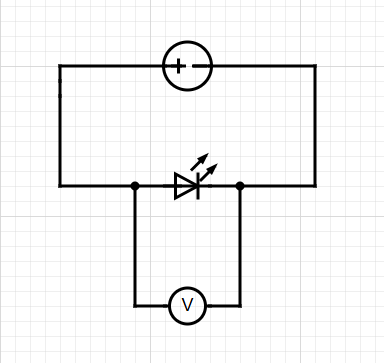  

**Notes:**  

**About accuracy:** 

## Execution

In [192]:
# Measurements
kleuren = ["rood","oranje","geel","groen","blauw","paars"]

#Eerste meting
Vknee1 = [2.192, 2.234, 2.354, 2.507, 2.776, 3.277]

#Tweede meting
Vknee2 = [2.176, 2.228, 2.328, 2.551, 2.749, 3.292]

#Derde meting
Vknee3 = [2.185, 2.219, 2.361, 2.540, 2.791, 3.263]


**Observations:**  

**Notes:**  


## Processing


### Data processing and Fitting

Fitresultaten:
a (h*c) = 1.8928696187087364e-25 J·m
b       = 4.7432794904938076e-20 J
h_fit   = 6.3137745787482865e-34 J·s
h (echt)= 6.62607015e-34 J·s


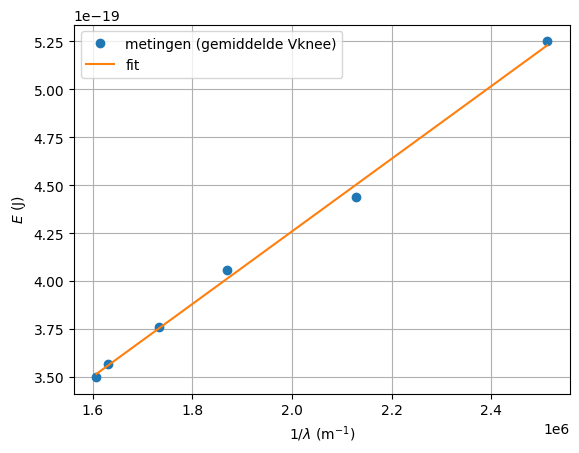

In [193]:
kleuren = ["rood","oranje","geel","groen","blauw","paars"]

lam_nm = np.array([622.0, 613.0, 577.0, 535.0, 470.0, 398.0])  # nm
lam_err_nm = np.array([14.0, 14.0, 15.0, 15.0, 15.0, 16.0])    # nm


Vknee1 = np.array([2.192, 2.234, 2.354, 2.507, 2.776, 3.277])
Vknee2 = np.array([2.176, 2.228, 2.328, 2.551, 2.749, 3.292])
Vknee3 = np.array([2.185, 2.219, 2.361, 2.540, 2.791, 3.263])

# --- constanten ---
e = 1.602176634e-19   # C
c = 2.998e8           # m/s

# --- gemiddeld Vknee ---
Vknee = (Vknee1 + Vknee2 + Vknee3) / 3

# --- x en y voor de fit ---
lam_m = lam_nm * 1e-9
inv_lam = 1 / lam_m             # 1/m

E = e * Vknee                   # Joule

# --- fitfunctie: E = a*(1/lam) + b ---
def line(x, a, b):
    return a*x + b

# beginwaarden
p0 = (1e-25, 0.0)

params, cov = curve_fit(line, inv_lam, E, p0=p0)
a_fit, b_fit = params

# a = h*c  -> h = a/c
h_fit = a_fit / c

print("Fitresultaten:")
print("a (h*c) =", a_fit, "J·m")
print("b       =", b_fit, "J")
print("h_fit   =", h_fit, "J·s")
print("h (echt)=", 6.62607015e-34, "J·s")

# --- plot ---
x_fit = np.linspace(inv_lam.min(), inv_lam.max(), 200)
y_fit = line(x_fit, a_fit, b_fit)

plt.figure()
plt.plot(inv_lam, E, "o", label="metingen (gemiddelde Vknee)")
plt.plot(x_fit, y_fit, "-", label="fit")
plt.xlabel(r"$1/\lambda\ \mathrm{(m^{-1})}$")
plt.ylabel(r"$E\ \mathrm{(J)}$")
plt.grid(True)
plt.legend()
plt.show()


#### Residual analysis


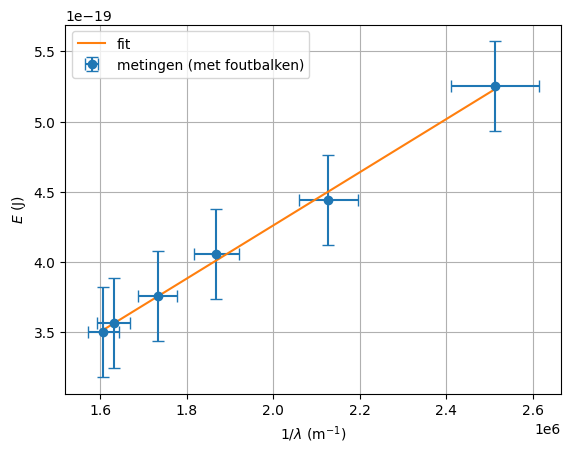

Fitresultaten (met onzekerheid):
a (h*c) = 1.8929e-25 ± 5.2e-27 J·m
b       = 4.7433e-20 ± 1.0e-20 J
h_fit   = 6.3138e-34 ± 1.7e-35 J·s
h (echt)= 6.6261e-34 J·s


In [194]:
# onzekerheden
V_err = 0.2                     # V
E_err = e * V_err                # J

lam_err_m = lam_err_nm * 1e-9    # m
inv_lam_err = lam_err_m / (lam_m**2)   # foutpropagatie: d(1/lam) = dlam/lam^2

plt.figure()
plt.errorbar(inv_lam, E,
             xerr=inv_lam_err, yerr=E_err,
             fmt="o", capsize=4, label="metingen (met foutbalken)")

plt.plot(x_fit, y_fit, "-", label="fit")
plt.xlabel(r"$1/\lambda\ \mathrm{(m^{-1})}$")
plt.ylabel(r"$E\ \mathrm{(J)}$")
plt.grid(True)
plt.legend()
plt.show()

a_fit, b_fit = params
a_err = np.sqrt(cov[0,0])
b_err = np.sqrt(cov[1,1])

# h = a/c
h_fit = a_fit / c
h_err = a_err / c

print("Fitresultaten (met onzekerheid):")
print(f"a (h*c) = {a_fit:.4e} ± {a_err:.1e} J·m")
print(f"b       = {b_fit:.4e} ± {b_err:.1e} J")
print(f"h_fit   = {h_fit:.4e} ± {h_err:.1e} J·s")
print(f"h (echt)= {6.62607015e-34:.4e} J·s")


In [195]:
# --- Agreement analysis zonder sigma-notatie ---

# geaccepteerde waarde
h_theory = 6.62607015e-34     # J s
u_h_theory = 0.0              # verwaarloosbaar

# verschil
Delta = h_fit - h_theory

# onzekerheid volgens foutpropagatie
u_Delta = np.sqrt(h_err**2 + u_h_theory**2)

print("Agreement analysis:")
print(f"Δ = {Delta:.3e} J·s")
print(f"u(Δ) = {u_Delta:.3e} J·s")
print(f"2·u(Δ) = {2*u_Delta:.3e} J·s")

# tegenstrijdigheidscriterium (Eq. 28)
if abs(Delta) > 2 * u_Delta:
    print(" Resultaat is INCONSISTENT met de theorie")
else:
    print("Resultaat is CONSISTENT met de theorie")


Agreement analysis:
Δ = -3.123e-35 J·s
u(Δ) = 1.723e-35 J·s
2·u(Δ) = 3.446e-35 J·s
Resultaat is CONSISTENT met de theorie


In [196]:
# Code om accuracy te bepalen

# Relatieve afwijking
rel_af = np.abs(Delta)/h_fit

# accuracy
accuracy =  100 - (1-rel_af) * 100

print("De accuracy van ons experiment is: ", accuracy, "%")



De accuracy van ons experiment is:  4.946257858221259 %



**Notes:**  


## Discussion


## Conclusion

## Additional notes, remarks, explanations, thoughts etc